# Building a RAG App 

This notebook implements a RAG system following Langchain's official documentation, adapted to use open source models:

- **LLM**: LLama via Ollama (not using any type of Gemini or OpenAI models)
- **Embeddings**: Sentence Transformers locally 
- **VectorStore**: InMemoryVectorStore (same as the documentation for now, but it can be better by using a ChromaDB)

## Overview

A typical RAG application have 2 principal components:
1. **Indexing**: pipeline to ingest data from a source and index them
2. **Retrieval and Generation**: RAG chain that gets the user query/input and fetches relevant data from the index

Basically being the flow:

**Store** -> **Retrieve** -> **Generate**

# Setup and Installation

Firstly, you are going to install the necessary dependencies to our RAG system

In [4]:
%pip install --quiet --upgrade langchain-text-splitters langchain-community langgraph
%pip install --quiet --upgrade langchain-huggingface
%pip install --quiet --upgrade langchain-ollama sentence-transformers
%pip install --quiet --upgrade beautifulsoup4 requests


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Components

Let's go to select 3 principal components to this notebook, which are:

1. **Chat Model**: LLama via Ollama
2. **Embeddings Model**: Sentence Transformers (local)
3. **Vector Store**: InMemoryVectorStore (simple and efficient)


In [5]:
import os
from langchain_ollama.chat_models import ChatOllama

os.environ["OLLAMA_BASE_URL"] = "http://localhost:11434"

llm = ChatOllama(
    model="llama3.2",
    temperature=0.1,
    base_url="http://localhost:11434",
)

print(f"Model: {llm.model}")
print(f"Temperature: {llm.temperature}")

Model: llama3.2
Temperature: 0.1


In [6]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

print(f"Embedding model: {embeddings.model_name}")
print(f"Embedding device: {embeddings.model_kwargs['device']}")

Embedding model: sentence-transformers/all-MiniLM-L6-v2
Embedding device: cpu


In [7]:
from langchain_core.vectorstores import InMemoryVectorStore

vector_store = InMemoryVectorStore(embeddings)

print("MemoryStore configured.")

MemoryStore configured.


# Preview

Now I am going to create a simple RAG pipeline that answers questions about a specific website

Following Langchain's documentation accordingly, let's use the blog post "LLM Powered Autonomous Agents" from Lilian Weng as the source to demonstrate how does RAG function at all.

The complete pipeline will be implemented and include:
- **Load** the source data (website)
- **Split** the data in small chunks
- **Store** it in the vector store
- **Retrieve** relevant documents
- **Generate** answers based on the documents context

In [8]:
from typing import List, TypedDict
import bs4
from langchain import hub
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langgraph.graph import START, StateGraph

loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)

# Index chunks in the vector store
print(f"Indexing {len(all_splits)} chunks in the vector store...")
_ = vector_store.add_documents(documents=all_splits)

# Define prompt for question-answering
# Pulling the prompt from the hub, but you can also define it directly
# as a string if you prefer. Or in Langsmith or Langfuse.
prompt = hub.pull("rlm/rag-prompt")

print("RAG prompt loaded from LangChain Hub")
print(f"Prompt type: {type(prompt)}")

# Define the state for the RAG agent
class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

USER_AGENT environment variable not set, consider setting it to identify your requests.


Indexing 63 chunks in the vector store...


/home/joao/.cache/pypoetry/virtualenvs/roshi-rag-kyW4OOdz-py3.12/lib/python3.12/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/home/joao/.cache/pypoetry/virtualenvs/roshi-rag-kyW4OOdz-py3.12/lib/python3.12/site-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


RAG prompt loaded from LangChain Hub
Prompt type: <class 'langchain_core.prompts.chat.ChatPromptTemplate'>


In [9]:
response = graph.invoke({"question": "What is an agent?"})
print(response["answer"])

/home/joao/.cache/pypoetry/virtualenvs/roshi-rag-kyW4OOdz-py3.12/lib/python3.12/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


An agent is a system that perceives its environment, takes actions, and learns from the consequences of those actions to achieve a goal or set of goals. In the context of LLM-powered autonomous agents, the LLM serves as the brain, making decisions based on planning, reflection, and refinement, while also relying on memory for reliability and parsing model output. The agent's primary function is to optimize believability at the moment versus in time.


# RAG APP: Part 2 - Conversational memory & Agents

This is the follow up of the previous RAG implementation in this notebook, now focusing on an agentic approach with memory integration.

## New resources:

1. Conversational Memory: Allow back and forth conversations with history
2. Tool calling
3. Chains
4. Agents

## Differences from part 1:

1. State based in messages, instead of separate keys
2. Tool calling for contextualized queries
3. Persistent memories between conversations
4. Agents for iterative retrieval

For that, i'll use the same data from Part 1 (blog post)

# Chains: Conversational RAG with Tool Calling


First, lets implement **Chains** - a more predictable approach that executes one retrieval step per user question

## Main changes
1. MessagesState: State based in the message sequence
2. As said previously, tool calling with retrieval
3. Contextualization: Generated queries considering the message history

## Message flow:
- HumanMessage
- AIMessage (with tool calls, query for the vector store)
- ToolMessage (retrieved documents)
- AIMessage (final answer)

In [10]:
from langgraph.graph import MessagesState, StateGraph


# Use MessagesState, built-in state for chat-like interactions
graph_builder = StateGraph(MessagesState)

print("Graph builder initialized with MessagesState.")

Graph builder initialized with MessagesState.


In [11]:
from langchain_core.tools import tool

@tool(response_format="content_and_artifact")
def retrieve(query: str):
    """Retrieve information related to a query (user question)"""
    retrieved_docs = vector_store.similarity_search(query)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\nContent: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs

print("Retrieve tool defined.")

Retrieve tool defined.


In [12]:
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode

def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond to user query."""
    llm_with_tools = llm.bind_tools([retrieve])
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

tools = ToolNode([retrieve])

def generate(state: MessagesState):
    """Generate answer using retrieved context"""
    # Get the last ToolMessage
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        if message.type == "tool":
            recent_tool_messages.append(message)
        else:
            break

    tool_messages = recent_tool_messages[::-1]

    # format context for llm
    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. If you don't know the answer, say that you "
        "don't know. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"
    )

    # Filter out tool calls and system messages
    conversation_messages = [
        message for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]

    prompt = [SystemMessage(system_message_content)] + conversation_messages

    response = llm.invoke(prompt)
    return {"messages": [response]}

print("🏗️ Three nodes created:")
print("  1. query_or_respond - Decides retrieval vs direct response")
print("  2. tools - Executes retrieval")  
print("  3. generate - Creates final answer")

🏗️ Three nodes created:
  1. query_or_respond - Decides retrieval vs direct response
  2. tools - Executes retrieval
  3. generate - Creates final answer


In [13]:
from langgraph.graph import END
from langgraph.prebuilt import tools_condition

graph_builder.add_node("query_or_respond", query_or_respond)
graph_builder.add_node("tools", tools)
graph_builder.add_node("generate", generate)

graph_builder.set_entry_point("query_or_respond")

graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "tools"},
)

graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)

conversational_graph = graph_builder.compile()


print("Conversational RAG graph compiled successfully")
print("Flow: query_or_respond → [tools] → generate → END")
print("Can short-circuit for direct responses (greetings, etc.)")

Conversational RAG graph compiled successfully
Flow: query_or_respond → [tools] → generate → END
Can short-circuit for direct responses (greetings, etc.)


In [14]:
# Code block to test the conversational RAG agent, finally

print("Testing Conversational RAG System")
print("=" * 30)

# test 1
print("Test 1: Direct response (no retrieval needed)")
input_message = "Hello"

for step in conversational_graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

print("-" * 30)

print("Test 2: Retrieval needed")
input_message = "What is Task Decomposition?"

for step in conversational_graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()


Testing Conversational RAG System
Test 1: Direct response (no retrieval needed)
================================ Human Message =================================

Hello
================================== Ai Message ==================================
Tool Calls:
  retrieve (813076b4-68d1-4769-a272-8485593b7cc6)
 Call ID: 813076b4-68d1-4769-a272-8485593b7cc6
  Args:
    query: Hello
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Prompt LM with 100 most recent observations and to generate 3 most salient high-level questions given a set of observations/statements. Then ask LM to answer those questions.


Planning & Reacting: translate the reflections and the environment information into actions

Planning is essentially in order to optimize believability at the moment vs in time.
Prompt template: {Intro of an agent X}. Here is X's plan today in broad strokes: 

/home/joao/.cache/pypoetry/virtualenvs/roshi-rag-kyW4OOdz-py3.12/lib/python3.12/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


================================== Ai Message ==================================

Hello! How can I assist you today? Do you have a question or task related to the provided context about agent architecture and reinforcement learning?
------------------------------
Test 2: Retrieval needed
================================ Human Message =================================

What is Task Decomposition?
================================== Ai Message ==================================
Tool Calls:
  retrieve (fbafe2a7-3b31-4d85-ba2b-f2dc9acad33f)
 Call ID: fbafe2a7-3b31-4d85-ba2b-f2dc9acad33f
  Args:
    query: Task Decomposition
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a st

/home/joao/.cache/pypoetry/virtualenvs/roshi-rag-kyW4OOdz-py3.12/lib/python3.12/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


================================== Ai Message ==================================

Task decomposition is a technique used to break down complex tasks into smaller, simpler steps. This can be done through various methods, including using simple prompting with instructions like "Steps for XYZ.\n1.", or by utilizing task-specific instructions, such as writing a story outline. Another approach involves relying on an external classical planner to generate a plan based on a domain-specific PDDL (Planning Domain Definition Language) description.


# Stateful Management of Chat History

Now we're going to add persistent memory (already done in our application) to the RAG chatbot

## Features

1. LangGraph Persistance: Built-in persistance layer
2. Multiple Threads: Support to multiple conversations at the same time
3. Thread IDs: Identification to each of this new conversation
4. Automatic State Management: Messages are appended to the state with no effort

## How it works?

- Checkpointer: Saves the state each step
- Thread ID: As said previously, ID of the specific conversation
- State Accumulation: Messages accumulate themselves through the conversation

In [15]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

conversational_graph_with_memory = graph_builder.compile(checkpointer=memory)

# Config thread ID to identify specific conversation
config = {"configurable": {"thread_id": "abc123"}}

print(" MemorySaver configured")
print("Graph recompiled with persistent memory")

 MemorySaver configured
Graph recompiled with persistent memory


In [16]:
# Test the new system out
print(" Testing Conversational Memory")

print("\nFirst question:")
input_message = "What is Task Decomposition?"

for step in conversational_graph_with_memory.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

print("\n" + "=" * 40)

print("\nFollow-up question (testing memory):")
input_message = "Can you look up some common ways of doing it?"

for step in conversational_graph_with_memory.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()


print("\n Note: The model contextualized 'it' as Task Decomposition!")

 Testing Conversational Memory

First question:
================================ Human Message =================================

What is Task Decomposition?
================================== Ai Message ==================================
Tool Calls:
  retrieve (7a094682-2228-4c56-b186-c6c25f1412ed)
 Call ID: 7a094682-2228-4c56-b186-c6c25f1412ed
  Args:
    query: Task Decomposition
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.
Another quite distinct approach, LLM+P (Liu et al. 2023), involves relying on an external classical planner to do long-horizon planning. This approach utilizes the Planning Domain 

/home/joao/.cache/pypoetry/virtualenvs/roshi-rag-kyW4OOdz-py3.12/lib/python3.12/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


================================== Ai Message ==================================

Task decomposition is a technique used to break down complex tasks into smaller, simpler steps. This can be done through various methods such as using simple prompting, task-specific instructions, or human inputs. It helps models like LLMs (Large Language Models) to better understand and tackle complicated tasks by transforming big tasks into multiple manageable ones.


Follow-up question (testing memory):
================================ Human Message =================================

Can you look up some common ways of doing it?
================================== Ai Message ==================================
Tool Calls:
  retrieve (63306947-2ab9-432a-8b1f-501e28e41036)
 Call ID: 63306947-2ab9-432a-8b1f-501e28e41036
  Args:
    query: common methods for task decomposition
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianwe

/home/joao/.cache/pypoetry/virtualenvs/roshi-rag-kyW4OOdz-py3.12/lib/python3.12/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


================================== Ai Message ==================================

According to the retrieved context, there are three common ways of task decomposition:

1. Using simple prompting like "Steps for XYZ.\n1." or "What are the subgoals for achieving XYZ?".
2. Utilizing task-specific instructions, such as "Write a story outline." for writing a novel.
3. Relying on an external classical planner to do long-horizon planning using the Planning Domain Definition Language (PDDL) as an intermediate interface.

 Note: The model contextualized 'it' as Task Decomposition!


# Agents: Multi-Step Retrieval RAG

Now we're going to implement Agents - an approach that permits the LLM to execute multiple steps of retrieval to answer a complex question

## Key difference from Chains (previous cells)

1. Iterative Retrieval: Can do multiple searches
2. LLM Decision Making: LLM decides when search more information
3. Loop Structure: Tool invocation returns to the original LLM
4. Less Predictable: More flexible, but the behavior may be less predictable

## **Agent Flow:**
- **Question** → **LLM** → **Tool Call** → **LLM** → **Answer or More Tools**

Now lets use the `create_react_agent` of LangGraph to create an ReAct agent. (obviously :P)

In [ ]:
from langgraph.prebuilt import create_react_agent

# Create agent executor with LLM, tools and memory
agent_executor = create_react_agent(llm, [retrieve], checkpointer=memory)

print("ReAct Agent created successfully!")
print("Tools available: [retrieve]")
print("Memory: MemorySaver (persistent)")
print("Agent can perform iterative retrieval")

🤖 ReAct Agent created successfully!
🛠️ Tools available: [retrieve]
💾 Memory: MemorySaver (persistent)
🔄 Agent can perform iterative retrieval


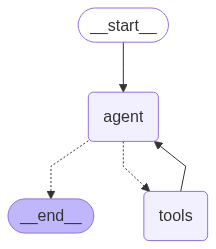

Agent graph visualized above


In [19]:
# Visualize the graph agent (optional)
try:
    from IPython.display import Image, display
    display(Image(agent_executor.get_graph().draw_mermaid_png()))
    print("Agent graph visualized above")
except Exception as e:
    print("Agent graph structure:")
    print("   LLM → Tool Decision → [Execute Tools] → LLM → Answer/More Tools")
    print(f"   (Visualization not available: {e})")

In [20]:
# Create RAG agent using create_react_agent
print(" Testing Multi-Step RAG Agent")
print("-" * 50)

config = {"configurable": {"thread_id": "def234"}}

input_message = (
    "What is the standard method for Task Decomposition?\n\n"
    "Once you get the answer, look up common extensions of that method."
)

print(f"Complex question made (more than 2 requests in the same input) -> {input_message}")
print("\nAgent execution steps:")
print("-" * 40)

for event in agent_executor.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    event["messages"][-1].pretty_print()
    print("-" * 20)

print("\nNote: Agent performed multiple retrieval steps autonomously!")

 Testing Multi-Step RAG Agent
--------------------------------------------------
Complex question made (more than 2 requests in the same input) -> What is the standard method for Task Decomposition?

Once you get the answer, look up common extensions of that method.

Agent execution steps:
----------------------------------------
================================ Human Message =================================

What is the standard method for Task Decomposition?

Once you get the answer, look up common extensions of that method.
--------------------
================================== Ai Message ==================================
Tool Calls:
  retrieve (4c1d2b15-aeb0-49db-9b6e-765d3d1c4187)
 Call ID: 4c1d2b15-aeb0-49db-9b6e-765d3d1c4187
  Args:
    query: standard method for Task Decomposition
--------------------
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Cont

/home/joao/.cache/pypoetry/virtualenvs/roshi-rag-kyW4OOdz-py3.12/lib/python3.12/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


================================== Ai Message ==================================

When it comes to task decomposition, there are several standard methods that can be used. One of the most common approaches is called "Chain of Thought" (CoT), which involves instructing the model to break down a complex task into smaller, more manageable steps. This technique helps the model think step by step and utilize more test-time computation to decompose hard tasks.

Another approach is "Tree of Thoughts," which extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be done using breadth-first search (BFS) or depth-first search (DFS), with each state evaluated by a classifier or majority vote.

In addition to these methods, there are also approaches that rely on external classical planners to do long-horizon planning. These approac

# Summary and Next Steps

## What we accomplished?
### Part 1: Basic RAG
- Document loading and chunking
- Vector store with embeddings
- Simple retrieve -> generate pipeline

### Part 2: Conversational RAG
- Chains: Tool calling with MessagesState
- Memory: Persistent chat history with thread IDs
- Agents: Multi-step iterative retrieval


## Next steps to integrate in your project (will do it in this one for my next steps, wish me luck!):

1. Create RAG Agent in the multi-agent system
2. Integrate it with the supervisor agent for intelligent routing
3. Add it to the graph of the project
4. Configure memory (PostgresSQL for Production)
5. Test integration with the chat endpoint or any test file

# Ready for Implementation/Production:
Hope this tutorial find itself useful for any1 who read it till here, mostly used Langchain's documentation to implement this notebook, but made some personal changes to be 100% free to understand the flow and use any open-source embeddings, vector stores and LLMs (it may affect your performance).
